In [1]:
using JSON
using Plots
using ProgressBars
using StableRNGs

using BootstrapAsymptotics

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


In [1]:
alpha_range    = exp10.(range(-1.0, stop=3.0, length=50))
exp_alpha_range= exp10.(range(-1.0, stop=2.0, length=10))

lambda        = 1.0
max_iteration = 50

50

┌ Warning: No strict ticks found
└ @ PlotUtils /Users/clarte/.julia/packages/PlotUtils/jEGKP/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/clarte/.julia/packages/PlotUtils/jEGKP/src/ticks.jl:191


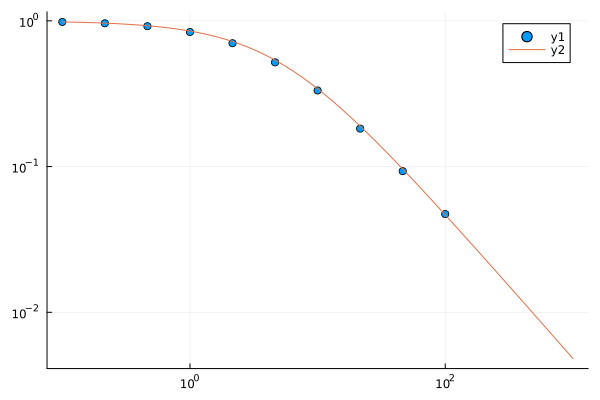

┌ Warning: No strict ticks found
└ @ PlotUtils /Users/clarte/.julia/packages/PlotUtils/jEGKP/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/clarte/.julia/packages/PlotUtils/jEGKP/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/clarte/.julia/packages/PlotUtils/jEGKP/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/clarte/.julia/packages/PlotUtils/jEGKP/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/clarte/.julia/packages/PlotUtils/jEGKP/src/ticks.jl:191


In [10]:
# trial for the BayesOpt estimator
rng = StableRNG(0)

d = 100

exp_variances = []
variances     = []

for α in exp_alpha_range
    problem = Logistic(λ = 1.0, ρ = 1., α = α)
    bias, variance = bias_variance_empirical(StableRNG(0), problem, BayesOpt(); n = floor(Int, α * d), K=1)
    push!(exp_variances, variance)
end

for α in alpha_range
    problem = Logistic(λ = 1.0, ρ = 1., α = α)
    result = state_evolution(problem, BayesOpt(), BayesOpt(), rtol=1e-5)
    push!(variances, 1.0 - result.overlaps.Q[1, 1])
end

scatter(exp_alpha_range, exp_variances, axis=:log)
plot!(alpha_range, variances, axis=:log)

In [ ]:
α = 2.0
d = 100

bias_variance_empirical(AbstractRNG(0), Logistic(α = α, ρ = 1.0, λ = 1.0), BayesOpt(); floor(α * d), 1)

In [28]:
bootstrap_bootstrap_overlaps        = []
bootstrap_bootstrap_hat_overlaps    = []

for alpha in alpha_range
    println("alpha = $alpha, lambda = $lambda")
    ov, hat_ov = state_evolution(
        Logistic(; α=alpha, λ=lambda),
        PairBootstrap(; p_max=10),
        PairBootstrap(; p_max=10);
        rtol=1e-4,
        max_iteration=100,
        show_progress=false
    )
    push!(bootstrap_bootstrap_overlaps, ov)
    push!(bootstrap_bootstrap_hat_overlaps, hat_ov)
end

alpha = 0.1, lambda = 1.0


alpha = 0.12067926406393285, lambda = 1.0


alpha = 0.14563484775012436, lambda = 1.0


alpha = 0.1757510624854792, lambda = 1.0


alpha = 0.2120950887920191, lambda = 1.0


...

alpha = 471.48663634573944, lambda = 1.0


alpha = 568.9866029018299, lambda = 1.0


alpha = 686.6488450042998, lambda = 1.0


alpha = 828.6427728546843, lambda = 1.0


alpha = 1000.0, lambda = 1.0


In [29]:
# save the overlaps into a file
filename = "data/logistic/bootstrap_bootstrap_overlaps_lambda=$lambda.json"

dict_to_save = Dict("alpha" => alpha_range,
                    "m"   => [o.m[1] for o in bootstrap_bootstrap_overlaps],
                    "q_diag"   => [o.Q[1, 1] for o in bootstrap_bootstrap_overlaps],
                    "q_off_diag"   => [o.Q[1, 2] for o in bootstrap_bootstrap_overlaps],
                    "v"   => [o.V[1] for o in bootstrap_bootstrap_overlaps],

                    "mhat"=> [o.m[1] for o in bootstrap_bootstrap_hat_overlaps],
                    "qhat_diag"=> [o.Q[1, 1] for o in bootstrap_bootstrap_hat_overlaps],
                    "qhat_off_diag"=> [o.Q[1, 2] for o in bootstrap_bootstrap_hat_overlaps],
                    "vhat"=> [o.V[1] for o in bootstrap_bootstrap_hat_overlaps],
                    )

open(filename, "w") do f
    write(f, JSON.json(dict_to_save))
end

8687

--- 

Compute the correlation between Bootstrap and ERM on full data

In [30]:
bootstrap_full_overlaps    = []
bootstrap_full_hat_overlaps    = []

for alpha in alpha_range
    println("alpha = $alpha, lambda = $lambda")
    
    ov, hat_ov = state_evolution(
        Logistic(; α=alpha, λ=lambda),
        FullResampling(),
        PairBootstrap(; p_max=10)
        ;
        rtol=1e-4,
        max_iteration=100,
        show_progress=false
    )
    push!(bootstrap_full_overlaps, ov)
    push!(bootstrap_full_hat_overlaps, hat_ov)
end

alpha = 0.1, lambda = 1.0


alpha = 0.12067926406393285, lambda = 1.0


alpha = 0.14563484775012436, lambda = 1.0


alpha = 0.1757510624854792, lambda = 1.0


alpha = 0.2120950887920191, lambda = 1.0


...

alpha = 471.48663634573944, lambda = 1.0


alpha = 568.9866029018299, lambda = 1.0


alpha = 686.6488450042998, lambda = 1.0


alpha = 828.6427728546843, lambda = 1.0


alpha = 1000.0, lambda = 1.0


In [31]:
# save the overlaps into a file
filename = "data/logistic/bootstrap_full_overlaps_lambda=$lambda.json"

dict_to_save = Dict("alpha" => alpha_range,
                          "m"   => [o.m[1] for o in bootstrap_full_overlaps],
                          "q_diag"   => [o.Q[1, 1] for o in bootstrap_full_overlaps],
                          "q_off_diag"   => [o.Q[1, 2] for o in bootstrap_full_overlaps],
                          "v"   => [o.V[1] for o in bootstrap_full_overlaps],
                          
                          "mhat"=> [o.m[1] for o in bootstrap_full_hat_overlaps],
                          "qhat_diag"=> [o.Q[1, 1] for o in bootstrap_full_hat_overlaps],
                          "qhat_off_diag"=> [o.Q[1, 2] for o in bootstrap_full_hat_overlaps],
                          "vhat"=> [o.V[1] for o in bootstrap_full_hat_overlaps],
                          )

open(filename, "w") do f
    write(f, JSON.json(dict_to_save))
end

8689

--- 

Compute the correlation between two resample of the full dataset

In [32]:
full_full_overlaps    = []
full_full_hat_overlaps    = []

for alpha in alpha_range
    println("alpha = $alpha, lambda = $lambda")
    ov, hat_ov = state_evolution(
        Logistic(; α=alpha, λ=lambda),
        FullResampling(),
        FullResampling();
        rtol=1e-3,
        max_iteration=100,
        show_progress=false
    )
    push!(full_full_overlaps, ov)
    push!(full_full_hat_overlaps, hat_ov)
end

alpha = 0.1, lambda = 1.0


alpha = 0.12067926406393285, lambda = 1.0
alpha = 0.14563484775012436, lambda = 1.0
alpha = 0.1757510624854792, lambda = 1.0


alpha = 0.2120950887920191, lambda = 1.0
alpha = 0.2559547922699536, lambda = 1.0
alpha = 0.3088843596477481, lambda = 1.0


alpha = 0.37275937203149406, lambda = 1.0
alpha = 0.4498432668969446, lambda = 1.0
alpha = 0.542867543932386, lambda = 1.0


alpha = 0.6551285568595508, lambda = 1.0
alpha = 0.79060432109077, lambda = 1.0
alpha = 0.9540954763499939, lambda = 1.0


...

alpha = 222.29964825261956, lambda = 1.0
alpha = 268.26957952797244, lambda = 1.0


alpha = 323.74575428176433, lambda = 1.0
alpha = 390.6939937054617, lambda = 1.0


alpha = 471.48663634573944, lambda = 1.0
alpha = 568.9866029018299, lambda = 1.0


alpha = 686.6488450042998, lambda = 1.0
alpha = 828.6427728546843, lambda = 1.0


alpha = 1000.0, lambda = 1.0


In [33]:
# save the overlaps into a file
filename = "data/logistic/full_full_overlaps_lambda=$lambda.json"

dict_to_save = Dict("alpha" => alpha_range,
                          "m"   => [o.m[1] for o in full_full_overlaps],
                          "q_diag"   => [o.Q[1, 1] for o in full_full_overlaps],
                          "q_off_diag"   => [o.Q[1, 2] for o in full_full_overlaps],
                          "v"   => [o.V[1] for o in full_full_overlaps],
                          
                          "mhat"=> [o.m[1] for o in full_full_hat_overlaps],
                          "qhat_diag"=> [o.Q[1, 1] for o in full_full_hat_overlaps],
                          "qhat_off_diag"=> [o.Q[1, 2] for o in full_full_hat_overlaps],
                          "vhat"=> [o.V[1] for o in full_full_hat_overlaps],
                          )

open(filename, "w") do f
    write(f, JSON.json(dict_to_save))
end

7962

--- 

Overlaps between two $y$ resampling 

In [34]:
lr_lr_overlaps    = []
lr_lr_hat_overlaps    = []

for alpha in alpha_range
    println("alpha = $alpha, lambda = $lambda")
    ov, hat_ov = state_evolution(
        Logistic(; α=alpha, λ=lambda),
        LabelResampling(),
        LabelResampling();
        rtol=1e-3,
        max_iteration=100,
        show_progress=false
    )
    push!(lr_lr_overlaps, ov)
    push!(lr_lr_hat_overlaps, hat_ov)
end

alpha = 0.1, lambda = 1.0


alpha = 0.12067926406393285, lambda = 1.0
alpha = 0.14563484775012436, lambda = 1.0


alpha = 0.1757510624854792, lambda = 1.0
alpha = 0.2120950887920191, lambda = 1.0


alpha = 0.2559547922699536, lambda = 1.0
alpha = 0.3088843596477481, lambda = 1.0


alpha = 0.37275937203149406, lambda = 1.0
alpha = 0.4498432668969446, lambda = 1.0


...

alpha = 471.48663634573944, lambda = 1.0


alpha = 568.9866029018299, lambda = 1.0


alpha = 686.6488450042998, lambda = 1.0


alpha = 828.6427728546843, lambda = 1.0


alpha = 1000.0, lambda = 1.0


In [35]:
# save the overlaps into a file
filename = "data/logistic/y_resampling_overlaps_lambda=$lambda.json"

dict_to_save = Dict("alpha" => alpha_range,
                          "m"   => [o.m[1] for o in lr_lr_overlaps],
                          "q_diag"   => [o.Q[1, 1] for o in lr_lr_overlaps],
                          "q_off_diag"   => [o.Q[1, 2] for o in lr_lr_overlaps],
                          "v"   => [o.V[1] for o in lr_lr_overlaps],
                          
                          "mhat"=> [o.m[1] for o in lr_lr_hat_overlaps],
                          "qhat_diag"=> [o.Q[1, 1] for o in lr_lr_hat_overlaps],
                          "qhat_off_diag"=> [o.Q[1, 2] for o in lr_lr_hat_overlaps],
                          "vhat"=> [o.V[1] for o in lr_lr_hat_overlaps],
                          )

open(filename, "w") do f
    write(f, JSON.json(dict_to_save))
end

8781

---

# "Residual" bootstrap for logistic regression

Here, we first train the model then we resample the labels according to the logistic model using $\hat w$ as teacher weight, then retrain our models.
So we just run SE for ERM, compute $q$ and then compute the y_resampling with $\rho = q$

In [36]:
erm_overlaps      = []
residual_overlaps = []

for alpha in alpha_range
    println("alpha = $alpha, lambda = $lambda")
    ov_erm, _ = state_evolution(Logistic(; α=alpha, λ=lambda), FullResampling(), FullResampling(), rtol=1e-3, max_iteration=100, show_progress=false)
    push!(erm_overlaps, ov_erm)
    ov, hat_ov = state_evolution(
        Logistic(ρ=ov_erm.Q[1, 1]; α=alpha, λ=lambda),
        LabelResampling(),
        LabelResampling();
        rtol=1e-4,
        max_iteration=100,
        show_progress=false
    )
    push!(residual_overlaps, ov)
end

alpha = 0.1, lambda = 1.0


alpha = 0.12067926406393285, lambda = 1.0


alpha = 0.14563484775012436, lambda = 1.0


alpha = 0.1757510624854792, lambda = 1.0


alpha = 0.2120950887920191, lambda = 1.0


...

alpha = 471.48663634573944, lambda = 1.0


alpha = 568.9866029018299, lambda = 1.0


alpha = 686.6488450042998, lambda = 1.0


alpha = 828.6427728546843, lambda = 1.0


alpha = 1000.0, lambda = 1.0


In [37]:
filename = "data/logistic/residual_bootstrap_overlaps_lambda=$lambda.json"

to_save = Dict([
    "alpha" => alpha_range,
    "m_erm" => [o.m[1] for o in erm_overlaps],
    "q_erm" => [o.Q[1] for o in erm_overlaps],
    "v_erm" => [o.V[1] for o in erm_overlaps],
    
    "q_diag" => [o.Q[1, 1] for o in residual_overlaps],
    "q_off_diag" => [o.Q[1, 2] for o in residual_overlaps],
    "m" => [o.m[1] for o in residual_overlaps],
])


open(filename, "w") do f
    write(f, JSON.json(to_save))
end

6851

# Subsampling and Jackknife

In [41]:
r = 0.99

ss_ss_overlaps    = []
ss_ss_hat_overlaps    = []

for alpha in alpha_range
    println("alpha = $alpha, lambda = $lambda")
    ov, hat_ov = state_evolution(
        Logistic(; α=alpha, λ=lambda),
        Subsampling(r = r), 
        Subsampling(r = r);
        rtol=1e-5,
        max_iteration=100,
        show_progress=false
    )
    push!(ss_ss_overlaps, ov)
    push!(ss_ss_hat_overlaps, hat_ov)
end

alpha = 0.1, lambda = 1.0


alpha = 0.12067926406393285, lambda = 1.0


alpha = 0.14563484775012436, lambda = 1.0


alpha = 0.1757510624854792, lambda = 1.0


alpha = 0.2120950887920191, lambda = 1.0


...

alpha = 471.48663634573944, lambda = 1.0


alpha = 568.9866029018299, lambda = 1.0


alpha = 686.6488450042998, lambda = 1.0


alpha = 828.6427728546843, lambda = 1.0


alpha = 1000.0, lambda = 1.0


In [42]:
filename = "data/logistic/subsampling_subsampling_overlaps_lambda=$(lambda)_p=$(r).json"


dict_to_save = Dict("alpha" => alpha_range,
                          "proba"         => r,
                          "m"             => [o.m[1] for o in ss_ss_overlaps],
                          "q_diag"        => [o.Q[1, 1] for o in ss_ss_overlaps],
                          "q_off_diag"    => [o.Q[1, 2] for o in ss_ss_overlaps],
                          "v"             => [o.V[1] for o in ss_ss_overlaps],
                          "mhat"          => [o.m[1] for o in ss_ss_hat_overlaps],
                          "qhat_diag"     => [o.Q[1, 1] for o in ss_ss_hat_overlaps],
                          "qhat_off_diag" => [o.Q[1, 2] for o in ss_ss_hat_overlaps],
                          "vhat"          => [o.V[1] for o in ss_ss_hat_overlaps],
                    )

open(filename, "w") do f
    write(f, JSON.json(dict_to_save))
end

8710

---

# Compute the Bayes-optimal estimator

In [45]:
bayes_optimal_q  = fill(0.0, length(alpha_range))
for i in eachindex(alpha_range)
    alpha = alpha_range[i]
    problem = Logistic(; α=alpha, λ=lambda)
    res = state_evolution_BayesOpt(problem, rtol=1e-6, max_iteration=100)
    bayes_optimal_q[i] = res.q
end

In [46]:
filename = "data/logistic/bayes_optimal_overlaps.json"

dict_to_save = Dict("alpha" => alpha_range,
                    "q" => bayes_optimal_q
                    )

open(filename, "w") do f
    write(f, JSON.json(dict_to_save))
end

1888